In [1]:
import pandas as pd

In [10]:
df = pd.read_csv("/home/tonnonssi/YOLO-Futures/logs/GOT_KL_hybrid/55_scaling_MultiState_77/I14_10steps.csv",
                    index_col=0)

In [26]:
def read_csv(f):
    df = pd.read_csv(f, index_col=0)
    df['ave_pnl_percent'] = (df['avg_pnl'] / 30_000_000 * 100).round(1)
    return df

In [27]:
basicCTTS = read_csv("/home/tonnonssi/YOLO-Futures/logs/GOT_KL_hybrid/55_scaling_MultiState_18/I12_10steps.csv")
klCTTS = read_csv("/home/tonnonssi/YOLO-Futures/logs/GOT_KL_hybrid/55_scaling_MultiState_17/I11latest.csv")
klDLinear = read_csv("/home/tonnonssi/YOLO-Futures/logs/DLinI11latest.csv")
klInformer = read_csv("/home/tonnonssi/YOLO-Futures/logs/Informer_I14latest.csv")

In [74]:
klCTTS.mean().round(2)

avg_pnl            1960030.27
avg_sharpe               0.79
avg_mdd                 -0.12
avg_winrate              0.48
ave_pnl_percent          6.54
dtype: float64

In [29]:
def get_full_df(typeof, lst):
    extract = [l[typeof] for l in lst]
    name = ['basicCTTS', 'klCTTS', 'klDLinear', 'klInformer']
    
    df = pd.concat(extract, axis=1)
    df.columns = name

    return df 

In [31]:
dfs = [basicCTTS, klCTTS, klDLinear, klInformer]

get_full_df("ave_pnl_percent", dfs)

,basicCTTS,klCTTS,klDLinear,klInformer
0,3.5,17.1,7.5,-10.6
1,3.4,27.8,4.7,-2.2
2,-1.6,23.2,10.8,-3.9
3,1.5,-1.0,-4.0,0.7
4,-1.5,-4.9,-4.0,0.2
5,1.7,6.9,-1.7,3.0
6,0.2,5.0,1.6,-0.5
7,-0.4,-2.2,-4.2,3.6
8,0.2,9.0,1.1,3.6
9,0.6,-1.4,1.8,-1.8


In [38]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

def plot_heatmap(df, type, vmax_percentile=95):
    """
    df: DataFrame (열 = 모델 이름, 행 = 지표 값들)
    vmax_percentile: 상위 몇 %를 색상 스케일의 최대값으로 클리핑할지 (기본=95%)
    """
    # 이상치 영향 줄이기 위해 상위 퍼센타일로 vmax 결정
    vmax = df.to_numpy().flatten()
    vmax = np.percentile(vmax, vmax_percentile)
    
    plt.figure(figsize=(8,6))
    sns.heatmap(
        df,
        annot=True, fmt=".1f", cmap="RdYlGn", center=0,
        vmin=None, vmax=vmax
    )
    plt.title(f"Performance Heatmap ({type})".format(vmax_percentile))
    plt.show()

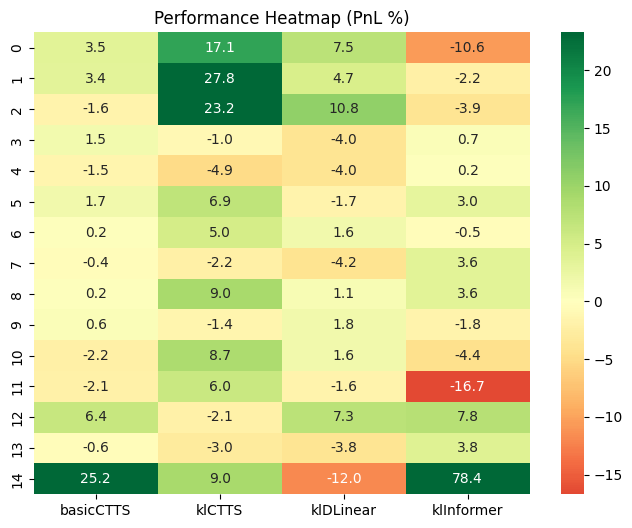

In [ ]:
# 사용 예시
dfs = [basicCTTS, klCTTS, klDLinear, klInformer]
full_df = get_full_df("ave_pnl_percent", dfs) 
plot_heatmap(full_df, "PnL %")

In [64]:
full_df = get_full_df("avg_winrate", dfs) * 100
full_df.mean()

basicCTTS     19.000000
klCTTS        48.000000
klDLinear     32.133333
klInformer    44.466667
dtype: float64

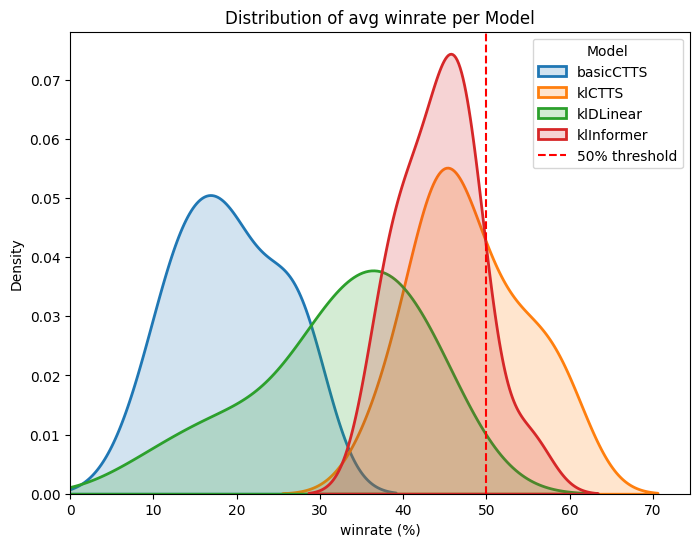

In [63]:
def plot_kde_overlaid(df):
    plt.figure(figsize=(8,6))
    
    for col in df.columns:
        sns.kdeplot(df[col], label=col, fill=True, alpha=0.2, linewidth=2)
    
    # 제목, 축 라벨
    plt.title("Distribution of avg winrate per Model")
    plt.xlabel("winrate (%)")
    plt.ylabel("Density")
    
    # 0.5 기준선 (빨간 점선)
    plt.axvline(50, color="red", linestyle="--", linewidth=1.5, label="50% threshold")
    
    # x축을 0부터 시작
    plt.xlim(left=0)
    
    plt.legend(title="Model")
    plt.show()

# 실행
plot_kde_overlaid(full_df)

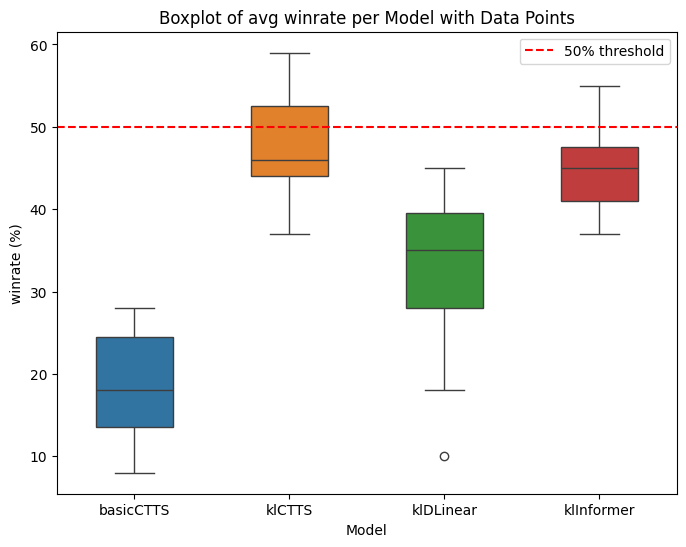

In [70]:
def plot_boxplot_with_points(df):
    plt.figure(figsize=(8,6))
    
    # KDE랑 동일한 색상 팔레트
    palette = {
        "basicCTTS": "tab:blue",
        "klCTTS": "tab:orange",
        "klDLinear": "tab:green",
        "klInformer": "tab:red"
    }
    
    # 박스플랏
    sns.boxplot(data=df, palette=palette, width=0.5)
    
    # 산점도 (swarmplot)
    # sns.swarmplot(data=df, palette=palette, size=5, alpha=0.3)
    
    # 제목/라벨
    plt.title("Boxplot of avg winrate per Model with Data Points")
    plt.ylabel("winrate (%)")
    plt.xlabel("Model")
    
    # 50% 기준선
    plt.axhline(50, color="red", linestyle="--", linewidth=1.5, label="50% threshold")
    
    plt.legend()
    plt.show()

# 실행
plot_boxplot_with_points(full_df)

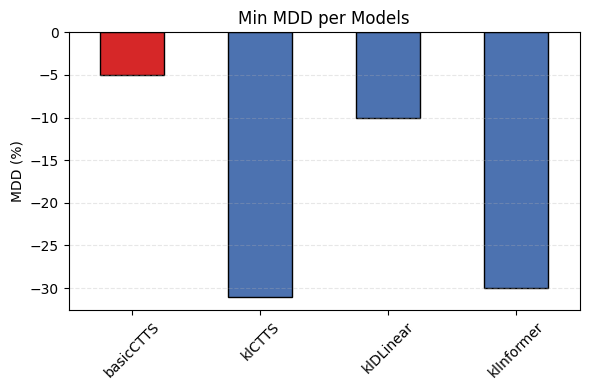

In [52]:
full_df = get_full_df("avg_mdd", dfs) 

# 평균값 계산
mean_df = pd.DataFrame(full_df.min()*100, columns=["avg_value"])

# 가장 큰 값 찾기
max_idx = mean_df["avg_value"].idxmax()

# 색상 지정 (최댓값만 빨강, 나머지는 파랑)
colors = ["#4C72B0" if idx != max_idx else "#D62728" for idx in mean_df.index]

# 막대 그래프
plt.figure(figsize=(6,4))
mean_df["avg_value"].plot(kind="bar", color=colors, edgecolor="black")

plt.title("Min MDD per Models")
plt.ylabel("MDD (%)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

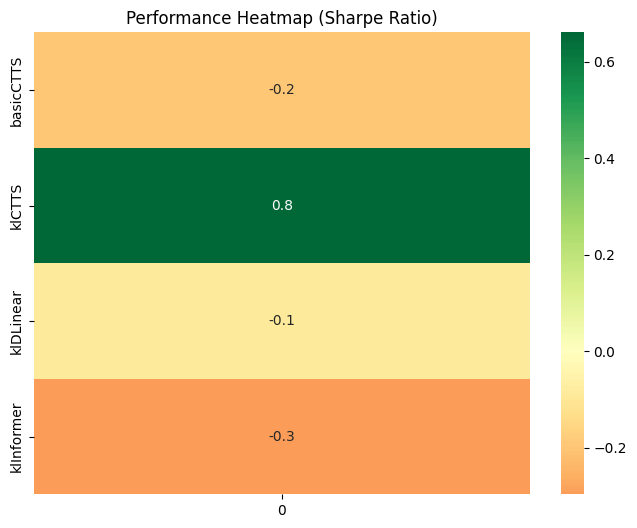

In [43]:
full_df = get_full_df("avg_sharpe", dfs)
plot_heatmap(pd.DataFrame(full_df.mean()), "Sharpe Ratio")

In [15]:
pd.concat([basicCTTS, klCTTS, klDLinear, klInformer], axis=1)

,avg_pnl,avg_sharpe,avg_mdd,avg_winrate,avg_pnl,avg_sharpe,avg_mdd,avg_winrate,avg_pnl,avg_sharpe,avg_mdd,avg_winrate,avg_pnl,avg_sharpe,avg_mdd,avg_winrate
0,1039075,0.31,-0.01,0.27,5142835,3.19,-0.06,0.59,2251422,1.18,-0.01,0.36,-3166408,-2.03,-0.16,0.44
1,1023422,-0.02,-0.03,0.12,8326463,2.75,-0.11,0.53,1408365,-0.02,-0.04,0.36,-665120,-0.66,-0.18,0.46
2,-484578,-1.25,-0.02,0.13,6963544,4.13,-0.07,0.59,3225675,0.71,-0.02,0.44,-1171627,-0.99,-0.14,0.49
3,436454,0.34,-0.01,0.26,-303618,-1.58,-0.10,0.45,-1203505,-0.92,-0.04,0.18,224374,-0.59,-0.11,0.37
4,-448230,-0.86,-0.02,0.18,-1478629,-1.74,-0.13,0.37,-1201760,-0.68,-0.06,0.10,70694,0.12,-0.12,0.41
5,504639,0.35,-0.01,0.20,2081980,1.46,-0.10,0.48,-523862,-0.93,-0.05,0.40,913302,-0.30,-0.11,0.48
6,55985,0.11,-0.00,0.14,1485718,-0.40,-0.11,0.49,494161,0.27,-0.07,0.35,-161256,-0.77,-0.15,0.39
7,-121233,-0.15,-0.02,0.17,-660617,-1.14,-0.11,0.43,-1250922,-1.74,-0.06,0.30,1067098,0.81,-0.08,0.43
8,64772,-0.36,-0.01,0.08,2694454,1.61,-0.12,0.52,337114,-0.41,-0.04,0.28,1088265,0.31,-0.15,0.48
9,179305,-0.08,-0.01,0.28,-420591,-0.42,-0.07,0.40,553379,0.58,-0.02,0.39,-543500,-0.85,-0.09,0.38


In [7]:
# file = '/home/tonnonssi/YOLO-Futures/logs/DLinI11latest.csv'
file = '/home/tonnonssi/YOLO-Futures/logs/Informer_I14latest.csv'
df = pd.read_csv(file,
index_col=0)

In [8]:
df['ave_pnl_percent'] = (df['avg_pnl'] / 30_000_000 * 100).round(1)
df

,avg_pnl,avg_sharpe,avg_mdd,avg_winrate,ave_pnl_percent
0,-3166408,-2.03,-0.16,0.44,-10.6
1,-665120,-0.66,-0.18,0.46,-2.2
2,-1171627,-0.99,-0.14,0.49,-3.9
3,224374,-0.59,-0.11,0.37,0.7
4,70694,0.12,-0.12,0.41,0.2
5,913302,-0.30,-0.11,0.48,3.0
6,-161256,-0.77,-0.15,0.39,-0.5
7,1067098,0.81,-0.08,0.43,3.6
8,1088265,0.31,-0.15,0.48,3.6
9,-543500,-0.85,-0.09,0.38,-1.8


In [9]:
df.sum().round()

avg_pnl            18347792.0
avg_sharpe               -4.0
avg_mdd                  -2.0
avg_winrate               7.0
ave_pnl_percent          61.0
dtype: float64

In [10]:
df.iloc[:-1].mean().round(2)

avg_pnl           -369299.21
avg_sharpe             -0.53
avg_mdd                -0.13
avg_winrate             0.44
ave_pnl_percent        -1.24
dtype: float64

In [11]:
df.mean().round(2)

avg_pnl            1223186.13
avg_sharpe              -0.30
avg_mdd                 -0.15
avg_winrate              0.44
ave_pnl_percent          4.07
dtype: float64

In [8]:
(df[['avg_pnl']].mean() / 30_000_000).round(3)

avg_pnl   -0.097
dtype: float64

In [9]:
df = pd.read_csv("/home/tonnonssi/YOLO-Futures/logs/GOT_KL_hybrid/55_scaling_MultiState_10/I9_3steps.csv")

In [10]:
df.iloc[:-1].mean().round(2)

Unnamed: 0          6.50
avg_pnl       -648550.14
avg_sharpe         -0.74
avg_mdd            -0.13
avg_winrate         0.43
dtype: float64

In [11]:
df.mean().round(2)

Unnamed: 0          7.00
avg_pnl        445031.07
avg_sharpe         -0.49
avg_mdd            -0.14
avg_winrate         0.43
dtype: float64

In [12]:
line = df.iloc[:14,:].mean().round(2)

In [13]:
df.iloc[:14, :].mean().round(2).sort_values(ascending=False)

Unnamed: 0          6.50
avg_winrate         0.43
avg_mdd            -0.13
avg_sharpe         -0.74
avg_pnl       -648550.14
dtype: float64